In [2]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
import seaborn as sns  # for nicer plots
sns.set(style="darkgrid")  # default style

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix as sk_confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow import keras
from keras import metrics
from keras.datasets import fashion_mnist
import keras_tuner as kt


tf.get_logger().setLevel('INFO')

In [3]:
#Data Ingestion
X_train = pd.read_csv("cleaned_x_train.csv")
Y_train = pd.read_csv("cleaned_y_train.csv")

X_val   = pd.read_csv("cleaned_x_val.csv")
Y_val   = pd.read_csv("cleaned_y_val.csv")

X_test  = pd.read_csv("cleaned_x_test.csv")
Y_test  = pd.read_csv("cleaned_y_test.csv")

In [4]:
#Shape of the data

datasets = {
    "X_train": X_train,
    "Y_train": Y_train,
    "X_val": X_val,
    "Y_val": Y_val,
    "X_test": X_test,
    "Y_test": Y_test
}

for name, arr in datasets.items():
    print(f"{name} shape: {arr.shape}")

X_train shape: (24158, 24)
Y_train shape: (24158, 1)
X_val shape: (5178, 24)
Y_val shape: (5178, 1)
X_test shape: (5177, 24)
Y_test shape: (5177, 1)


In [5]:
pd.DataFrame({
    "X_min": X_train.min(),
    "X_max": X_train.max(),
    "Y_min": Y_train.min(),
    "Y_max": Y_train.max()})

,X_min,X_max,Y_min,Y_max
ACEADNED,0.0,4.0,NaN,NaN
ACEADSAF,0.0,4.0,NaN,NaN
ACEDEPRS,0.0,1.0,NaN,NaN
ACEDIVRC,0.0,8.0,NaN,NaN
ACEDRINK,0.0,1.0,NaN,NaN
ACEDRUGS,0.0,1.0,NaN,NaN
ACEHURT1,0.0,2.0,NaN,NaN
ACEPRISN,0.0,1.0,NaN,NaN
ACEPUNCH,0.0,2.0,NaN,NaN
ACESWEAR,0.0,2.0,NaN,NaN


In [ ]:
# scale some x features and convert y values to 0/1
cols_to_scale = ["ACEHURT1", "ACEPUNCH", "ACESWEAR", "ACETOUCH", "ACETTHEM",
                "ACEADNED", "ACEADSAF", "ACEDIVRC", "_SMOKER3", "_EDUCAG",
                "MENTHLTH", "PHYSHLTH", "_AGE80", "ACE_SCORE"]

scaler = StandardScaler()

X_train[cols_to_scale ] = scaler.fit_transform(X_train[cols_to_scale])
X_val[cols_to_scale]   = scaler.transform(X_val[cols_to_scale])
X_test[cols_to_scale]  = scaler.transform(X_test[cols_to_scale])

Y_train = Y_train.squeeze().astype(int)
Y_val   = Y_val.squeeze().astype(int)
Y_test  = Y_test.squeeze().astype(int)

In [23]:
#1 number of sneaker images
print("Number of Risky Drinkers:", sum(Y_train == 1))
#2 number of non-sneaker images
print("Number of Non-Risky Drinkers:", sum(Y_train == 0))
#3 majority class in Y_train
class_counts = np.bincount(Y_train)
majority = class_counts.argmax()
if majority == 0:
    print("Majority Class: Non-Risky Drinkers")
else:
    print("Majority Class: Risky Drinkers")
#4 accuracy of majority class in Y_train
print("Accuracy of The Majority Class:", class_counts.max() / len(Y_train))

Number of Risky Drinkers: 9110
Number of Non-Risky Drinkers: 15048
Majority Class: Non-Risky Drinkers
Accuracy of The Majority Class: 0.6228992466263763


In [ ]:
def build_model(num_features, learning_rate):
  """

  Args:
    num_features: The number of input features.
    learning_rate: The desired learning rate for SGD.

  Returns:
    model: A tf.keras model (graph).
  """

  tf.keras.backend.clear_session()
  tf.random.set_seed(0)


  model = tf.keras.Sequential()
  model.add(tf.keras.layers.Dense(
      units=1,        
      input_shape=(num_features,),  
      use_bias=True,              
      activation="sigmoid",
      kernel_initializer=tf.keras.initializers.Ones(),  
      bias_initializer=tf.keras.initializers.Ones(),    
  ))

  optimizer = tf.keras.optimizers.SGD(learning_rate=learning_rate)


  model.compile(optimizer=optimizer,
                  loss="binary_crossentropy",
                  metrics=["accuracy"])
    
  return model

Epoch 1/5


/opt/anaconda3/envs/ml-env/lib/python3.10/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-11-30 22:12:15.761071: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Pro
2025-11-30 22:12:15.761296: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2025-11-30 22:12:15.761312: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2025-11-30 22:12:15.761856: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-11-30 22:12:15.762004: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Cre

755/755 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.4815 - loss: 2.8726 - val_accuracy: 0.4859 - val_loss: 2.7248
Epoch 2/5
755/755 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.4814 - loss: 2.8424 - val_accuracy: 0.4861 - val_loss: 2.6961
Epoch 3/5
755/755 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.4813 - loss: 2.8124 - val_accuracy: 0.4859 - val_loss: 2.6676
Epoch 4/5
755/755 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.4811 - loss: 2.7825 - val_accuracy: 0.4851 - val_loss: 2.6392
Epoch 5/5
755/755 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.4805 - loss: 2.7527 - val_accuracy: 0.4853 - val_loss: 2.6110


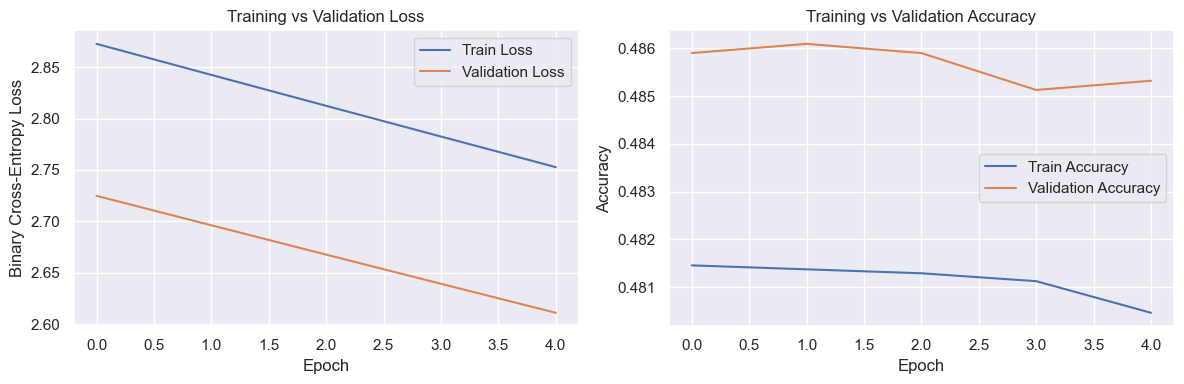

In [25]:
tf.random.set_seed(0)
# 2. Build and compile model

model_tf = build_model(num_features=X_train.shape[1], learning_rate=0.0001)

# 3. Fit the model

history = model_tf.fit(
    X_train, Y_train,
    epochs=5,
    batch_size=32,
    validation_data=(X_val, Y_val),
    verbose=1
)
# 4. Generate (1,2) plot
plt.figure(figsize=(12, 4))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("Training vs Validation Loss")
plt.legend()

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

Trial 4 Complete [00h 01m 24s]
val_loss: 0.6246440410614014

Best val_loss So Far: 0.6207596659660339
Total elapsed time: 00h 05m 41s
Best learning rate: 0.1


/opt/anaconda3/envs/ml-env/lib/python3.10/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


First five weights: [-0.0158199  -0.0007217  -0.01553334 -0.01023857  0.00165375]
Bias term: -0.09550981968641281
Final train loss: 0.6225
Final val loss:   0.6206
Val - Train loss diff: -0.0019


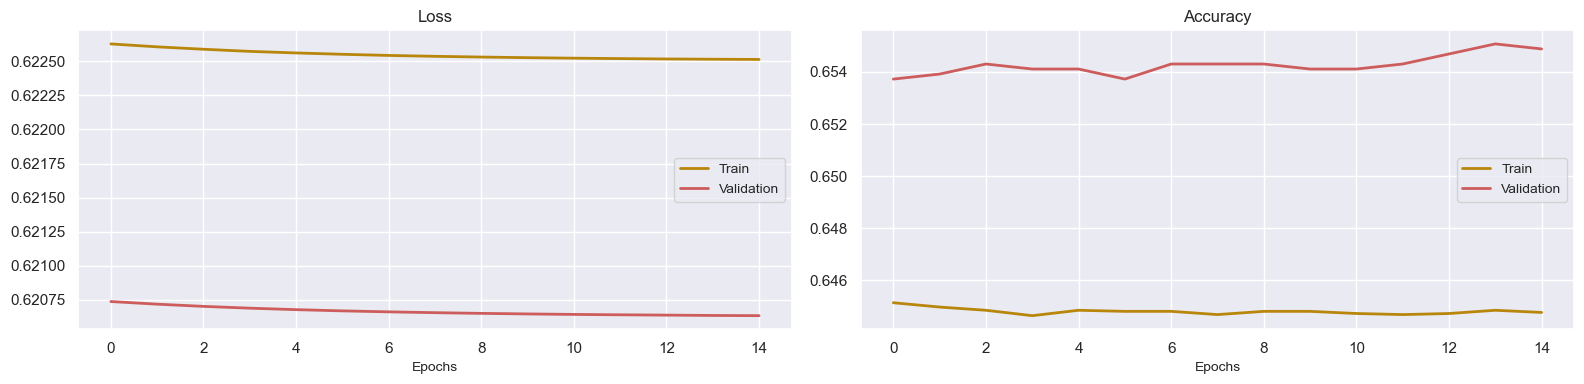

In [ ]:
# 1) Define a tuner 
def build_model_tuner(hp):
    model = keras.Sequential()
    model.add(keras.layers.Dense(
        units=1,
        input_shape=(X_train.shape[1],),
        activation="sigmoid",
        use_bias=True,
        kernel_initializer=tf.keras.initializers.Ones(),
        bias_initializer=tf.keras.initializers.Ones(),
    ))

    # Tune the learning rate
    lr = hp.Choice("learning_rate", [0.1, 1e-4, 1e-3, 1e-2])
    optimizer = keras.optimizers.SGD(learning_rate=lr)

    model.compile(optimizer=optimizer,
                  loss="binary_crossentropy",
                  metrics=["accuracy"])
    return model

# 2) Create tuner 
tuner = kt.RandomSearch(
    build_model_tuner,
    objective="val_loss",
    max_trials=5,
    overwrite=True,
    directory="w207_project",
    project_name="final_project"
)

# 3) Run tuner search
tuner.search(
    X_train, Y_train,
    validation_data=(X_val, Y_val),
    epochs=15,   
    verbose=1
)

# 4) Retrieve best hyperparameters and model
best_hp = tuner.get_best_hyperparameters(1)[0]
print("Best learning rate:", best_hp.get("learning_rate"))

best_model = tuner.get_best_models(1)[0]

# Re-train with best settings for clarity
history = best_model.fit(
    X_train, Y_train,
    validation_data=(X_val, Y_val),
    epochs=15,
    batch_size=32,
    verbose=0
)



# First five learned parameters (weights + bias)
W, b = best_model.layers[0].get_weights()
W = W.reshape(-1)
print("First five weights:", W[:5])
print("Bias term:", float(b[0]))

# Final-epoch loss on train and val
final_train_loss = history.history["loss"][-1]
final_val_loss   = history.history["val_loss"][-1]
print(f"Final train loss: {final_train_loss:.4f}")
print(f"Final val loss:   {final_val_loss:.4f}")

# 4) Difference between train and val
print(f"Val - Train loss diff: {final_val_loss - final_train_loss:.4f}")



#Plots
fig = plt.figure(figsize=(16, 4))

#loss
ax = fig.add_subplot(1, 2, 1)
plt.plot(history.history['loss'], lw=2, color='darkgoldenrod')
plt.plot(history.history['val_loss'], lw=2, color='indianred')
plt.legend(['Train', 'Validation'], fontsize=10)
ax.set_xlabel('Epochs', size=10)
ax.set_title('Loss')


#accuracy
ax = fig.add_subplot(1, 2, 2)
plt.plot(history.history['accuracy'], lw=2, color='darkgoldenrod')
plt.plot(history.history['val_accuracy'], lw=2, color='indianred')
plt.legend(['Train', 'Validation'], fontsize=10)
ax.set_xlabel('Epochs', size=10)
ax.set_title('Accuracy')


plt.tight_layout()
plt.show()


In [ ]:
# Evaluation
# Evaluate on training set
train_loss, train_acc = best_model.evaluate(X_train, Y_train, verbose=0)
print(f"Train Accuracy: {train_acc:.4f}")

# Evaluate on test set
test_loss, test_acc = best_model.evaluate(X_test, Y_test, verbose=0)
print(f"Test Accuracy: {test_acc:.4f}")

Train Accuracy: 0.6475
Test Accuracy: 0.6556


162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


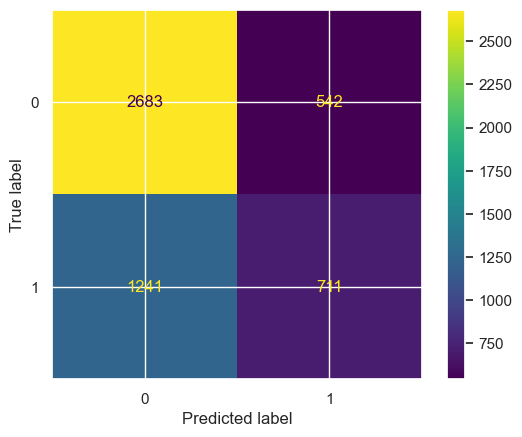

True_Positive: 711 False_Negative: 1241 False_Positive: 542 True_Negative: 2683
Risky Drinker Accuracy on Test Data: 0.3642
Non-Risky Drinker Accuracy on Test Data: 0.8319
755/755 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Risky Drinker Accuracy on Train Data:     0.3372
Non-Risky Drinker Accuracy on Train Data: 0.8353


In [ ]:

# Test predictions
y_pred = (best_model.predict(X_test) > 0.5).astype(int).ravel()
cm = sk_confusion_matrix(Y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

#Test cm
tn, fp, fn, tp = cm.ravel()
print("True_Positive:", tp, "False_Negative:", fn, "False_Positive:", fp, "True_Negative:", tn)


risky_acc = tp / (tp + fn) if (tp + fn) > 0 else 0   
non_risky_acc = tn / (tn + fp) if (tn + fp) > 0 else 0 

print(f"Risky Drinker Accuracy on Test Data: {risky_acc:.4f}")
print(f"Non-Risky Drinker Accuracy on Test Data: {non_risky_acc:.4f}")


# Train predictions 
y_train_pred = (best_model.predict(X_train) >= 0.5).astype(int).ravel()

# Train cm
cm_train = sk_confusion_matrix(Y_train, y_train_pred)
tn_t, fp_t, fn_t, tp_t = cm_train.ravel()

risky_acc_train     = tp_t / (tp_t + fn_t) if (tp_t + fn_t) else 0.0
non_risky_acc_train = tn_t / (tn_t + fp_t) if (tn_t + fp_t) else 0.0

print(f"Risky Drinker Accuracy on Train Data:     {risky_acc_train:.4f}")
print(f"Non-Risky Drinker Accuracy on Train Data: {non_risky_acc_train:.4f}")

In [30]:
from sklearn.utils.class_weight import compute_class_weight


weights = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0,1]),
    y=Y_train
)
class_weights = {0:weights[0], 1:weights[1]}


Trial 5 Complete [00h 01m 41s]
val_loss: 0.6215736269950867

Best val_loss So Far: 0.616969883441925
Total elapsed time: 00h 08m 35s
Best learning rate: 0.001


/opt/anaconda3/envs/ml-env/lib/python3.10/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/opt/anaconda3/envs/ml-env/lib/python3.10/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 6 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


First five weights: [-0.05075937 -0.04080113 -0.03972594 -0.04529792 -0.08509262]
Bias term: 0.43797194957733154
Final train loss: 0.6468
Final val loss:   0.6428
Val - Train loss diff: -0.0040


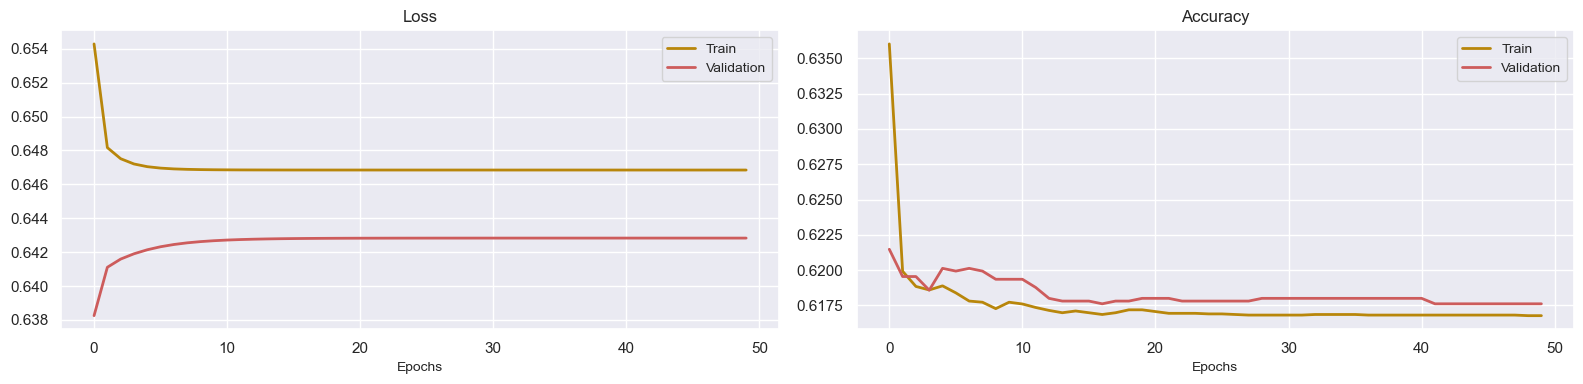

In [32]:
# 1) Define a tuner with glorot_uniform kernel initializer and fit the model with class_weights hyperparameter to reduce the effect of class imbalance
def build_model_tuner2(hp):
    model = keras.Sequential()
    model.add(keras.layers.Dense(
        units=1,
        input_shape=(X_train.shape[1],),
        activation="sigmoid",
        use_bias=True,
        kernel_initializer="glorot_uniform",
        bias_initializer=tf.keras.initializers.Ones(),
    ))

    # Tune the learning rate
    lr = hp.Choice("learning_rate", [0.1, 0.2, 1e-4, 1e-3, 1e-2])
    optimizer = keras.optimizers.Adam(learning_rate=lr)

    model.compile(optimizer=optimizer,
                  loss="binary_crossentropy",
                  metrics=["accuracy"])
    return model

# 2) Create tuner 
tuner = kt.RandomSearch(
    build_model_tuner2,
    objective="val_loss",
    max_trials=5,
    overwrite=True,
    directory="w207_project",
    project_name="final_project"
)

# 3) Run tuner search
tuner.search(
    X_train, Y_train,
    validation_data=(X_val, Y_val),
    epochs=15,   
    verbose=1
)

# 4) Retrieve best hyperparameters and model
best_hp = tuner.get_best_hyperparameters(1)[0]
print("Best learning rate:", best_hp.get("learning_rate"))

log_model = tuner.get_best_models(1)[0]

# Retrain with best settings for clarity
history = log_model.fit(
    X_train, Y_train,
    validation_data=(X_val, Y_val),
    epochs=50,
    batch_size=32,
    class_weight=class_weights,
    verbose=0
    
)



# 2) First five learned parameters (weights + bias)
W, b = log_model.layers[0].get_weights()
W = W.reshape(-1)
print("First five weights:", W[:5])
print("Bias term:", float(b[0]))

# 3) Final-epoch loss on train and val
final_train_loss = history.history["loss"][-1]
final_val_loss   = history.history["val_loss"][-1]
print(f"Final train loss: {final_train_loss:.4f}")
print(f"Final val loss:   {final_val_loss:.4f}")

# 4) Difference between train and val
print(f"Val - Train loss diff: {final_val_loss - final_train_loss:.4f}")



#Plots
fig = plt.figure(figsize=(16, 4))

#loss
ax = fig.add_subplot(1, 2, 1)
plt.plot(history.history['loss'], lw=2, color='darkgoldenrod')
plt.plot(history.history['val_loss'], lw=2, color='indianred')
plt.legend(['Train', 'Validation'], fontsize=10)
ax.set_xlabel('Epochs', size=10)
ax.set_title('Loss')


#accuracy
ax = fig.add_subplot(1, 2, 2)
plt.plot(history.history['accuracy'], lw=2, color='darkgoldenrod')
plt.plot(history.history['val_accuracy'], lw=2, color='indianred')
plt.legend(['Train', 'Validation'], fontsize=10)
ax.set_xlabel('Epochs', size=10)
ax.set_title('Accuracy')


plt.tight_layout()
plt.show()
